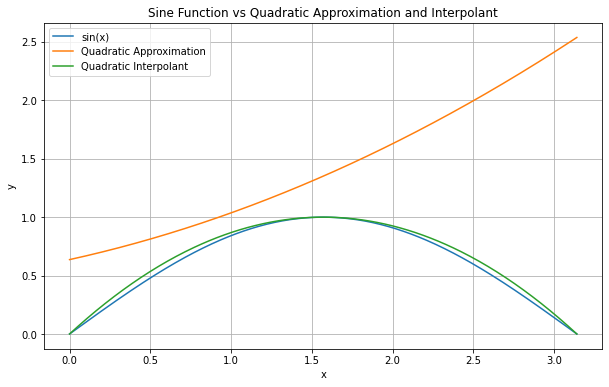

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Define the sine function
def f(x):
    return np.sin(x)

# Define the standard L2 inner product
def inner_product(f, g, a, b):
    integrand = lambda x: f(x) * g(x)
    return quad(integrand, a, b)[0]

# Quadratic basis functions
def phi_0(x):
    return 1

def phi_1(x):
    return x

def phi_2(x):
    return x**2

# Compute the coefficients for the optimal L2 quadratic approximation
a, b = 0, np.pi
coefficients = []
for phi in [phi_0, phi_1, phi_2]:
    numerator = inner_product(f, phi, a, b)
    denominator = inner_product(phi, phi, a, b)
    coefficients.append(numerator / denominator)

# Define the quadratic approximation function
def quadratic_approximation(x):
    return coefficients[0] * phi_0(x) + coefficients[1] * phi_1(x) + coefficients[2] * phi_2(x)

# Quadratic interpolant of sin(x) with nodes x0 = 0, x1 = π/2, x2 = π
def quadratic_interpolant(x):
    return (4/np.pi**2) * x * (np.pi - x)

# Generate x values
x_values = np.linspace(0, np.pi, 400)

# Plot the sine function, quadratic approximation, and quadratic interpolant
plt.figure(figsize=(10, 6))
plt.plot(x_values, np.sin(x_values), label='sin(x)')
plt.plot(x_values, [quadratic_approximation(x) for x in x_values], label='Quadratic Approximation')
plt.plot(x_values, [quadratic_interpolant(x) for x in x_values], label='Quadratic Interpolant')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sine Function vs Quadratic Approximation and Interpolant')
plt.legend()
plt.grid(True)
plt.show()
